In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import itertools
from memory_profiler import memory_usage
%matplotlib inline

In [14]:
# --- Divide and Conquer Algorithms ---
def merge_sort(arr):
    """
    Implements a classic Divide and Conquer sorting algorithm.
    Time Complexity: O(n log n)
    """
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]
        
        merge_sort(L)
        merge_sort(R)
        
        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1
            
        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1
            
        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

def bubble_sort(arr):
    """
    Implements a simple comparison-based sorting algorithm.
    Time Complexity: O(n^2)
    """
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
# --- Profiling & Timing Results ---
input_sizes = [100, 500, 1000, 2000, 5000]
merge_times = []
bubble_times = []
print(f"{'n':<10} | {'Merge Sort (s)':<15} | {'Bubble Sort (s)':<15}")
print("-" * 45)
for size in input_sizes:
    test_data = [random.randint(0, 10000) for _ in range(size)]
    # Profile Merge Sort
    data_copy = test_data.copy()
    start = time.time()
    merge_sort(data_copy)
    m_time = time.time() - start
    merge_times.append(m_time)
    # Profile Bubble Sort
    data_copy = test_data.copy()
    start = time.time()
    bubble_sort(data_copy)
    b_time = time.time() - start
    bubble_times.append(b_time)
    print(f"{size:<10} | {m_time:<15.5f} | {b_time:<15.5f}")

n          | Merge Sort (s)  | Bubble Sort (s)
---------------------------------------------
100        | 0.00000         | 0.00101        
500        | 0.00100         | 0.02283        
1000       | 0.00390         | 0.11455        
2000       | 0.00800         | 0.43947        
5000       | 0.02361         | 2.99710        


n          | Merge Sort (s)  | Bubble Sort (s)
---------------------------------------------
100        | 0.00000         | 0.00000        
500        | 0.00000         | 0.02075        
1000       | 0.00405         | 0.10691        
2000       | 0.00632         | 0.46376        
5000       | 0.02360         | 3.43561        


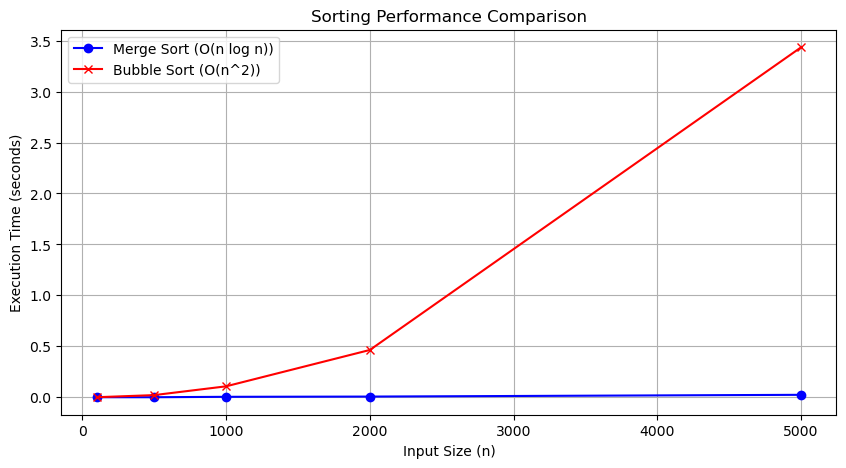

'\nOBSERVATION:\nMerge sort scales significantly better than Bubble sort for larger datasets. \nThis demonstrates the efficiency of Divide and Conquer techniques, where the \nO(n log n) complexity allows for near-linear scaling compared to the exponential \ngrowth of the O(n^2) Bubble sort.\n'

In [9]:
import matplotlib.pyplot as plt
# --- Visualization ---

plt.figure(figsize=(10, 5))
plt.plot(input_sizes, merge_times, label='Merge Sort (O(n log n))', marker='o', color='blue')
plt.plot(input_sizes, bubble_times, label='Bubble Sort (O(n^2))', marker='x', color='red')

plt.title('Sorting Performance Comparison')
plt.xlabel('Input Size (n)')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

# --- Observations ---

"""
OBSERVATION:
Merge sort scales significantly better than Bubble sort for larger datasets. 
This demonstrates the efficiency of Divide and Conquer techniques, where the 
O(n log n) complexity allows for near-linear scaling compared to the exponential 
growth of the O(n^2) Bubble sort.
"""

In [12]:
def fractional_knapsack(value, weight, capacity):
    # Calculate value/weight ratio
    index = list(range(len(value)))
    ratio = [v/w for v, w in zip(value, weight)]
    
    # Sort by ratio in descending order (Greedy Choice)
    index.sort(key=lambda i: ratio[i], reverse=True)
    
    max_value = 0
    fractions = [0] * len(value)
    
    for i in index:
        if weight[i] <= capacity:
            fractions[i] = 1
            max_value += value[i]
            capacity -= weight[i]
        else:
            fractions[i] = capacity / weight[i]
            max_value += value[i] * fractions[i]
            break
            
    return max_value, fractions

values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50

max_val, fractions = fractional_knapsack(values, weights, capacity)
print(f"Greedy Fractional Knapsack Output:")
print(f"Maximum Value: {max_val}")
print(f"Fractions taken of each item: {fractions}")
print("Observation: The greedy strategy is highly efficient here, simply sorting by value-to-weight ratio to maximize profit.")

Greedy Fractional Knapsack Output:
Maximum Value: 240.0
Fractions taken of each item: [1, 1, 0.6666666666666666]
Observation: The greedy strategy is highly efficient here, simply sorting by value-to-weight ratio to maximize profit.


In [5]:
def knapsack_dp(W, wt, val, n):
    # Initialize DP table
    K = [[0 for x in range(W + 1)] for x in range(n + 1)]
    
    # Build table K[][] in bottom-up manner
    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                K[i][w] = 0
            elif wt[i-1] <= w:
                K[i][w] = max(val[i-1] + K[i-1][w-wt[i-1]], K[i-1][w])
            else:
                K[i][w] = K[i-1][w]
                
    return K[n][W], K

val = [60, 100, 120]
wt = [10, 20, 30]
W = 50
n = len(val)

max_dp_val, dp_table = knapsack_dp(W, wt, val, n)
print(f"0/1 Knapsack DP Maximum Value: {max_dp_val}")
print("DP Table (showing optimal substructure):")
for row in dp_table:
    print(row)

0/1 Knapsack DP Maximum Value: 220
DP Table (showing optimal substructure):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 220]


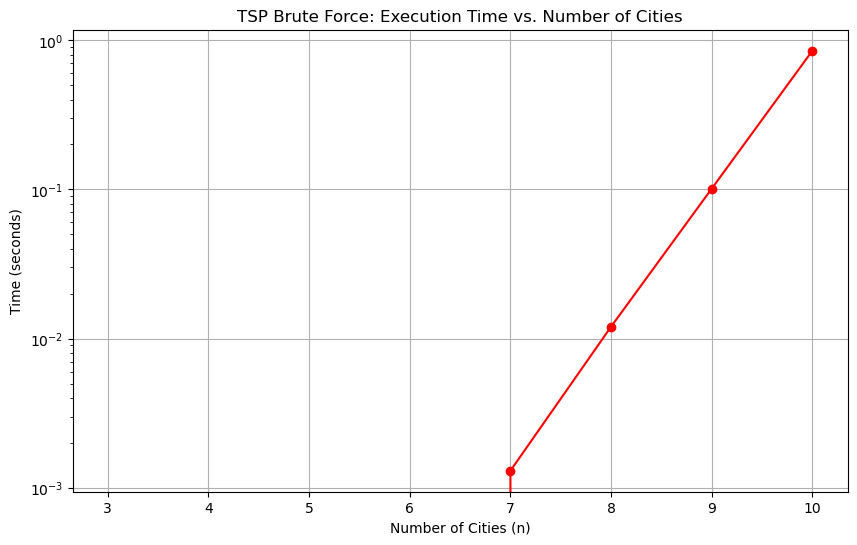

Observation: Notice how the curve becomes almost vertical. This is the 'Combinatorial Explosion'.


In [7]:
def calculate_distance(path, distance_matrix):
    """Calculates the total distance of a given route."""
    total_dist = 0
    for i in range(len(path) - 1):
        total_dist += distance_matrix[path[i]][path[i+1]]
    # Return to starting city
    total_dist += distance_matrix[path[-1]][path[0]]
    return total_dist
def solve_tsp_brute_force(distance_matrix):
    """Finds the optimal path by checking all permutations."""
    num_cities = len(distance_matrix)
    cities = list(range(num_cities))
    min_path = None
    min_distance = float('inf')
    # Generate all possible permutations (starting from city 0)
    for path in itertools.permutations(cities[1:]):
        current_path = (0,) + path
        current_dist = calculate_distance(current_path, distance_matrix)
        if current_dist < min_distance:
            min_distance = current_dist
            min_path = current_path
    return min_path, min_distance
def generate_random_matrix(n):
    matrix = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            dist = random.randint(10, 100)
            matrix[i][j] = matrix[j][i] = dist
    return matrix
sizes = [3, 4, 5, 6, 7, 8, 9, 10]
execution_times = []
for n in sizes:
    matrix = generate_random_matrix(n)
    start_time = time.time()
    solve_tsp_brute_force(matrix)
    execution_times.append(time.time() - start_time)
# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(sizes, execution_times, marker='o', linestyle='-', color='red')
plt.title('TSP Brute Force: Execution Time vs. Number of Cities')
plt.xlabel('Number of Cities (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.yscale('log') # Log scale helps visualize the rapid growth
plt.show()

In [16]:
import time
import matplotlib.pyplot as plt

# 1. Naive Recursion (Exponential Time)
def fib_recursive(n):
    if n <= 1:
        return n
    return fib_recursive(n-1) + fib_recursive(n-2)

# 2. Dynamic Programming - Bottom Up (Linear Time)
def fib_dp(n):
    if n <= 1:
        return n
    table = [0] * (n + 1)
    table[1] = 1
    for i in range(2, n + 1):
        table[i] = table[i-1] + table[i-2]
    return table[n]

In [17]:
# 1. Recursive Brute Force
def knapsack_recursive(W, wt, val, n):
    if n == 0 or W == 0:
        return 0
    if wt[n-1] > W:
        return knapsack_recursive(W, wt, val, n-1)
    else:
        return max(val[n-1] + knapsack_recursive(W - wt[n-1], wt, val, n-1),
                   knapsack_recursive(W, wt, val, n-1))

# 2. Dynamic Programming Approach
def knapsack_dp(W, wt, val, n):
    K = [[0 for x in range(W + 1)] for x in range(n + 1)]
    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                K[i][w] = 0
            elif wt[i-1] <= w:
                K[i][w] = max(val[i-1] + K[i-1][w-wt[i-1]], K[i-1][w])
            else:
                K[i][w] = K[i-1][w]
    return K[n][W]

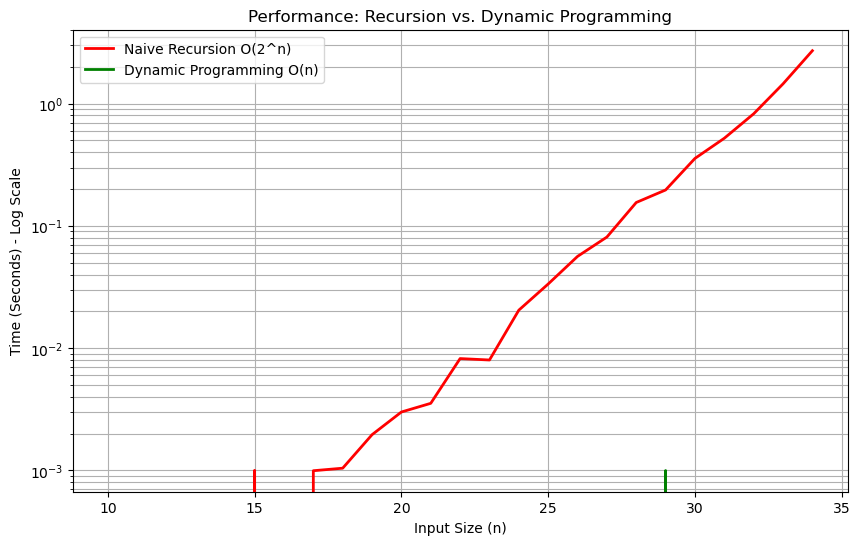

In [18]:
def plot_performance():
    n_values = range(10, 35)  # Testing small range because recursion is slow
    rec_times = []
    dp_times = []

    for n in n_values:
        # Time Recursive
        start = time.time()
        fib_recursive(n)
        rec_times.append(time.time() - start)
        
        # Time DP
        start = time.time()
        fib_dp(n)
        dp_times.append(time.time() - start)

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, rec_times, label='Naive RecSursion O(2^n)', color='red', linewidth=2)
    plt.plot(n_values, dp_times, label='Dynamic Programming O(n)', color='green', linewidth=2)
    plt.yscale('log') # Log scale helps see the massive difference
    plt.title('Performance: Recursion vs. Dynamic Programming')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Time (Seconds) - Log Scale')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.show()

plot_performance()